# Day 1: FAISS

FAISS (Facebook AI Similarity Search) is Meta's open-source library for efficient similarity search and clustering of dense vectors. It is written in C++ with a Python wrapper, supports both CPU and GPU, and handles datasets ranging from a few thousand to billions of vectors.

FAISS is the natural starting point for this book because it exposes the full index selection journey more clearly than any other library. Rather than hiding the tradeoff between speed and accuracy behind a single API call, FAISS asks you to choose an index type explicitly. That choice - flat, IVF or HNSW - is the central lesson of this chapter.

## When would you reach for FAISS?

FAISS is the right choice when:

- You need exact or approximate nearest neighbor search in Python with minimal dependencies
- Your dataset fits in RAM and you want fast, well-benchmarked performance
- You want control over the index type and its parameters
- You are prototyping and want a library that scales from 10k to 100M vectors without changing your API calls

## The use case

Given a crime incident from the Nordvik dataset, find the ten most similar incidents by MO_TEXT embedding. We run the same query against three index types - Flat, IVF and HNSW - and measure recall and latency at each step. By the end of the chapter the reader understands not just how to use FAISS but why the index choice matters.

## 1. Install Dependencies

In [1]:
%pip install faiss-cpu==1.14.3 \
             numpy==2.2.6 \
             pandas==3.0.3 \
             pyarrow==25.0.0 \
             plotly==6.9.0 --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

In [2]:
import faiss
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import time

print(f"OK  FAISS version: {faiss.__version__}")

OK  FAISS version: 1.14.3


## 3. Load Data and Embeddings

In [3]:
df         = pd.read_parquet("data/nordvik_crimes.parquet")
embeddings = np.load("data/nordvik_embeddings.npy").astype("float32")
ids        = np.loadtxt("data/nordvik_ids.txt", dtype = str, encoding = "utf-8")

DIM = embeddings.shape[1]

print(f"OK  Dataset:    {len(df):,} rows")
print(f"OK  Embeddings: {embeddings.shape} {embeddings.dtype}")
print(f"OK  Dimensions: {DIM}")

OK  Dataset:    500,000 rows
OK  Embeddings: (500000, 384) float32
OK  Dimensions: 384


## 4. Choose a Query Incident

We pick a single burglary incident as our query and use it consistently across all three index types so the results are directly comparable.

In [4]:
QUERY_IDX = df[df["CrimeType"] == "Burglary"].index[0]
query_vec = embeddings[QUERY_IDX].reshape(1, -1)

print(f"Query incident: {df['IncidentID'].iloc[QUERY_IDX]}")
print(f"Crime type:     {df['CrimeType'].iloc[QUERY_IDX]}")
print(f"MO_TEXT:        {df['MO_TEXT'].iloc[QUERY_IDX]}")

Query incident: NVK-000004
Crime type:     Burglary
MO_TEXT:        At approx 1632hrs, Multiple offenders described as medium build, tall, wearing face covering gained entry to Residence - Single Family in Hartley Cross. Property taken: handbag, tablet. No FO identified.


## 5. Index 1 - IndexFlatL2 (Exact Search)

`IndexFlatL2` is the simplest FAISS index. It stores vectors as-is and computes exact L2 distances against every vector in the index at query time. There is no training step, no approximation and no parameters to tune. It is the ground truth against which every other index is measured.

The tradeoff is linear scaling - query time grows proportionally with the number of vectors. At 100k vectors on a laptop this is still fast enough for interactive use, but at 10M vectors it becomes impractical.

Since we normalized our embeddings in `generate_embeddings.ipynb`, L2 distance and cosine similarity are equivalent here: minimizing L2 distance is the same as maximizing cosine similarity on unit-norm vectors.

In [5]:
K = 10  # number of nearest neighbors to retrieve

index_flat = faiss.IndexFlatL2(DIM)
index_flat.add(embeddings)

print(f"OK  IndexFlatL2 built")
print(f"    Vectors indexed: {index_flat.ntotal:,}")

OK  IndexFlatL2 built
    Vectors indexed: 500,000


In [6]:
times = []
for _ in range(N_REPEATS := 50):
    start = time.perf_counter()
    distances_flat, indices_flat = index_flat.search(query_vec, K)
    times.append((time.perf_counter() - start) * 1000)
latency_flat = float(np.mean(times))

print(f"OK  IndexFlatL2 query complete ({latency_flat:.3f}ms avg over 50 runs)")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (idx, dist) in enumerate(zip(indices_flat[0], distances_flat[0]), 1):
    row = df.iloc[idx]
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {dist:<10.4f} {row['MO_TEXT'][:60]}...")

OK  IndexFlatL2 query complete (15.750ms avg over 50 runs)
Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0000     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.2831     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.2836     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.2968     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.3015     Multiple offenders described as medium build, short, wearing...
6      NVK-295844     Burglary         0.3106     At approx 0015hrs, Two offenders, slim build, short, wearing...
7      NVK-487821     Burglary         0.3166     Multiple offenders described as medium build, tall, wearin

## 6. Index 2 - IndexIVFFlat (Approximate Search with Inverted File)

`IndexIVFFlat` partitions the vector space into `nlist` Voronoi cells using k-means clustering. At query time it only searches the `nprobe` nearest cells rather than the entire index. This makes queries faster at the cost of potentially missing some true nearest neighbors - the approximation tradeoff.

Two parameters control the tradeoff:

- `nlist` - number of cells. More cells means faster queries but requires more training data and memory. A common starting point is `sqrt(n_vectors)`.
- `nprobe` - number of cells searched at query time. Higher values improve recall at the cost of speed. The default is 1; we will experiment with several values.

Unlike `IndexFlatL2`, an IVF index must be trained before adding vectors.

In [7]:
N = embeddings.shape[0]
nlist = int(np.sqrt(N))

quantizer  = faiss.IndexFlatL2(DIM)
index_ivf  = faiss.IndexIVFFlat(quantizer, DIM, nlist)

print(f"OK  Training IndexIVFFlat (nlist={nlist})...")
index_ivf.train(embeddings)
index_ivf.add(embeddings)

print(f"OK  IndexIVFFlat built")
print(f"    Vectors indexed: {index_ivf.ntotal:,}")
print(f"    nlist:           {nlist}")

OK  Training IndexIVFFlat (nlist=707)...
OK  IndexIVFFlat built
    Vectors indexed: 500,000
    nlist:           707


In [8]:
# Ground truth from flat index for recall calculation
true_neighbors = set(indices_flat[0].tolist())

N_REPEATS   = 50
ivf_results = []

for nprobe in [1, 5, 10, 20, 50]:
    index_ivf.nprobe = nprobe
    times = []
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        distances_ivf, indices_ivf = index_ivf.search(query_vec, K)
        times.append((time.perf_counter() - start) * 1000)
    latency = float(np.mean(times))
    recall  = len(set(indices_ivf[0].tolist()) & true_neighbors) / K
    ivf_results.append({"nprobe": nprobe, "recall": recall, "latency_ms": latency})
    print(f"nprobe={nprobe:<4} recall@{K}={recall:.2f}  latency={latency:.3f}ms (avg over {N_REPEATS} runs)")

df_ivf = pd.DataFrame(ivf_results)

nprobe=1    recall@10=0.40  latency=0.245ms (avg over 50 runs)
nprobe=5    recall@10=1.00  latency=0.157ms (avg over 50 runs)
nprobe=10   recall@10=1.00  latency=0.293ms (avg over 50 runs)
nprobe=20   recall@10=1.00  latency=0.500ms (avg over 50 runs)
nprobe=50   recall@10=1.00  latency=1.212ms (avg over 50 runs)


In [9]:
# Best nprobe results
index_ivf.nprobe = 10
distances_ivf, indices_ivf = index_ivf.search(query_vec, K)

print(f"IndexIVFFlat results (nprobe=10):\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (idx, dist) in enumerate(zip(indices_ivf[0], distances_ivf[0]), 1):
    row = df.iloc[idx]
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {dist:<10.4f} {row['MO_TEXT'][:60]}...")

IndexIVFFlat results (nprobe=10):

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0000     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.2831     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.2836     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.2968     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.3015     Multiple offenders described as medium build, short, wearing...
6      NVK-295844     Burglary         0.3106     At approx 0015hrs, Two offenders, slim build, short, wearing...
7      NVK-487821     Burglary         0.3166     Multiple offenders described as medium build, tall, wearing ...
8      NVK-434251 

## 7. Index 3 - IndexHNSWFlat (Hierarchical Navigable Small World)

HNSW builds a multi-layer graph of vectors where each node connects to its nearest neighbors. Queries traverse the graph from the top layer down, narrowing the search at each level. This produces excellent recall at low latency and requires no training step.

The key parameter is `M` - the number of connections per node. Higher values improve recall but increase memory use and build time. Values between 16 and 64 cover most use cases.

In [10]:
M = 32  # connections per node

index_hnsw = faiss.IndexHNSWFlat(DIM, M)

print(f"OK  Building IndexHNSWFlat (M={M})...")
start = time.perf_counter()
index_hnsw.add(embeddings)
build_time = time.perf_counter() - start

print(f"OK  IndexHNSWFlat built ({build_time:.1f}s)")
print(f"    Vectors indexed: {index_hnsw.ntotal:,}")
print(f"    M:               {M}")

OK  Building IndexHNSWFlat (M=32)...
OK  IndexHNSWFlat built (13.1s)
    Vectors indexed: 500,000
    M:               32


In [11]:
hnsw_results = []

for ef in [16, 32, 64, 128, 256]:
    index_hnsw.hnsw.efSearch = ef
    times = []
    for _ in range(N_REPEATS):
        start = time.perf_counter()
        distances_hnsw, indices_hnsw = index_hnsw.search(query_vec, K)
        times.append((time.perf_counter() - start) * 1000)
    latency = float(np.mean(times))
    recall  = len(set(indices_hnsw[0].tolist()) & true_neighbors) / K
    hnsw_results.append({"efSearch": ef, "recall": recall, "latency_ms": latency})
    print(f"efSearch={ef:<5} recall@{K}={recall:.2f}  latency={latency:.3f}ms (avg over {N_REPEATS} runs)")

df_hnsw = pd.DataFrame(hnsw_results)

efSearch=16    recall@10=1.00  latency=0.106ms (avg over 50 runs)
efSearch=32    recall@10=1.00  latency=0.037ms (avg over 50 runs)
efSearch=64    recall@10=1.00  latency=0.057ms (avg over 50 runs)
efSearch=128   recall@10=1.00  latency=0.110ms (avg over 50 runs)
efSearch=256   recall@10=1.00  latency=0.229ms (avg over 50 runs)


In [12]:
# Best efSearch results
index_hnsw.hnsw.efSearch = 64
distances_hnsw, indices_hnsw = index_hnsw.search(query_vec, K)

print(f"IndexHNSWFlat results (efSearch=64):\n")
print(f"{'Rank':<6} {'IncidentID':<14} {'CrimeType':<16} {'Distance':<10} {'MO_TEXT'}")
print("-" * 90)
for rank, (idx, dist) in enumerate(zip(indices_hnsw[0], distances_hnsw[0]), 1):
    row = df.iloc[idx]
    print(f"{rank:<6} {row['IncidentID']:<14} {row['CrimeType']:<16} {dist:<10.4f} {row['MO_TEXT'][:60]}...")

IndexHNSWFlat results (efSearch=64):

Rank   IncidentID     CrimeType        Distance   MO_TEXT
------------------------------------------------------------------------------------------
1      NVK-000004     Burglary         0.0000     At approx 1632hrs, Multiple offenders described as medium bu...
2      NVK-429593     Burglary         0.2831     Multiple offenders described as slim build, tall, wearing hi...
3      NVK-090521     Burglary         0.2836     Multiple offenders described as medium build, average, weari...
4      NVK-071545     Burglary         0.2968     Residence - Single Family in Hartley Cross targeted. Items r...
5      NVK-059565     Burglary         0.3015     Multiple offenders described as medium build, short, wearing...
6      NVK-295844     Burglary         0.3106     At approx 0015hrs, Two offenders, slim build, short, wearing...
7      NVK-487821     Burglary         0.3166     Multiple offenders described as medium build, tall, wearing ...
8      NVK-4342

## 8. Recall vs Latency Comparison

We now have recall and latency measurements for both IVF and HNSW across a range of parameter values. The flat index gives us the exact baseline at the cost of the highest latency.

In [13]:
print(f"{'Index':<20} {'Parameter':<20} {'Recall@10':<12} {'Latency (ms)'}")
print("-" * 65)
print(f"{'IndexFlatL2':<20} {'(exact)':<20} {'1.00':<12} {latency_flat:.2f}")
for row in ivf_results:
    print(f"{'IndexIVFFlat':<20} {f'nprobe={row["nprobe"]}':<20} {row['recall']:<12.2f} {row['latency_ms']:.2f}")
for row in hnsw_results:
    print(f"{'IndexHNSWFlat':<20} {f'efSearch={row["efSearch"]}':<20} {row['recall']:<12.2f} {row['latency_ms']:.2f}")

Index                Parameter            Recall@10    Latency (ms)
-----------------------------------------------------------------
IndexFlatL2          (exact)              1.00         15.75
IndexIVFFlat         nprobe=1             0.40         0.24
IndexIVFFlat         nprobe=5             1.00         0.16
IndexIVFFlat         nprobe=10            1.00         0.29
IndexIVFFlat         nprobe=20            1.00         0.50
IndexIVFFlat         nprobe=50            1.00         1.21
IndexHNSWFlat        efSearch=16          1.00         0.11
IndexHNSWFlat        efSearch=32          1.00         0.04
IndexHNSWFlat        efSearch=64          1.00         0.06
IndexHNSWFlat        efSearch=128         1.00         0.11
IndexHNSWFlat        efSearch=256         1.00         0.23


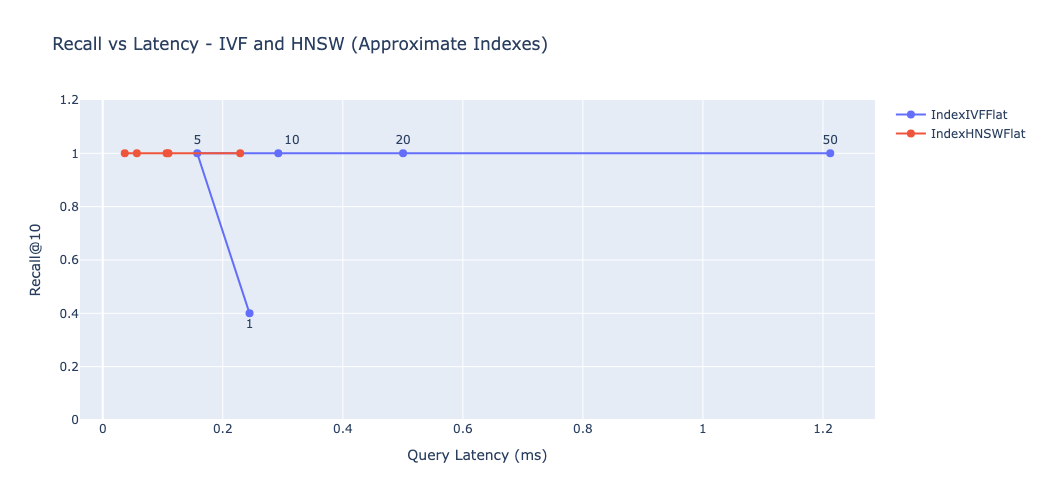

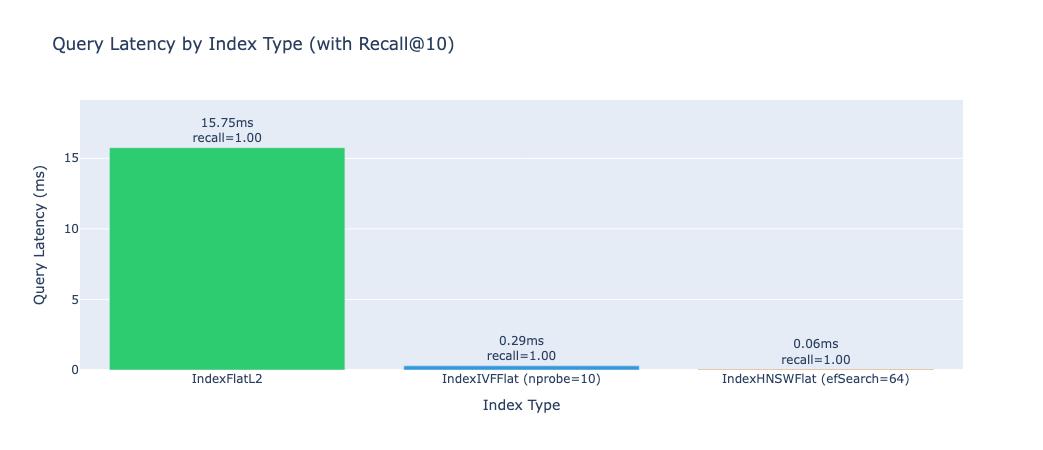

In [14]:
# Chart 1 - Recall vs Latency for approximate indexes
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x = df_ivf["latency_ms"],
    y = df_ivf["recall"],
    mode = "lines+markers+text",
    name = "IndexIVFFlat",
    text = [str(r) for r in df_ivf["nprobe"]],
    textposition = ["bottom center", "top center", "top right", "top center", "top center"],
    marker = {"size": 8},
))

fig1.add_trace(go.Scatter(
    x = df_hnsw["latency_ms"],
    y = df_hnsw["recall"],
    mode = "lines+markers",
    name = "IndexHNSWFlat",
    marker = {"size": 8},
))

fig1.update_layout(
    title = "Recall vs Latency - IVF and HNSW (Approximate Indexes)",
    xaxis_title = "Query Latency (ms)",
    yaxis_title = "Recall@10",
    yaxis = {"range": [0, 1.2]},
    width = 850,
    height = 500,
)
fig1.show()

# Chart 2 - Latency comparison across all three index types
fig2 = go.Figure()

index_names = ["IndexFlatL2", "IndexIVFFlat\n(nprobe=10)", "IndexHNSWFlat\n(efSearch=64)"]
latencies   = [
    latency_flat,
    df_ivf[df_ivf["nprobe"] == 10]["latency_ms"].values[0],
    df_hnsw[df_hnsw["efSearch"] == 64]["latency_ms"].values[0],
]
recalls = [
    1.0,
    df_ivf[df_ivf["nprobe"] == 10]["recall"].values[0],
    df_hnsw[df_hnsw["efSearch"] == 64]["recall"].values[0],
]

fig2.add_trace(go.Bar(
    x = index_names,
    y = latencies,
    name = "Latency (ms)",
    marker_color = ["#2ecc71", "#3498db", "#e67e22"],
    text = [f"{l:.2f}ms<br>recall={r:.2f}" for l, r in zip(latencies, recalls)],
    textposition = "outside",
))

fig2.update_layout(
    title = "Query Latency by Index Type (with Recall@10)",
    xaxis_title = "Index Type",
    yaxis_title = "Query Latency (ms)",
    width = 700,
    height = 450,
    showlegend = False,
)
fig2.show()

## 9. Scaling: How Does Latency Grow?

One of FAISS's genuine strengths is predictable scaling behavior. We now measure flat index query latency at four dataset sizes to show how it grows - and compare against IVF and HNSW at the same sizes.

In [15]:
sizes   = [10_000, 50_000, 100_000, 250_000, 500_000]
scaling = []

for size in sizes:
    subset = embeddings[:size]
    q      = query_vec

    # Flat
    idx_f = faiss.IndexFlatL2(DIM)
    idx_f.add(subset)
    t = []
    for _ in range(20):
        start = time.perf_counter()
        idx_f.search(q, K)
        t.append((time.perf_counter() - start) * 1000)
    lat_f = float(np.mean(t))

    # IVF
    nlist_s  = int(np.sqrt(size))
    quantizer_s = faiss.IndexFlatL2(DIM)
    idx_i    = faiss.IndexIVFFlat(quantizer_s, DIM, nlist_s)
    idx_i.train(subset)
    idx_i.add(subset)
    idx_i.nprobe = 10
    t = []
    for _ in range(20):
        start = time.perf_counter()
        idx_i.search(q, K)
        t.append((time.perf_counter() - start) * 1000)
    lat_i = float(np.mean(t))

    # HNSW
    idx_h = faiss.IndexHNSWFlat(DIM, M)
    idx_h.add(subset)
    idx_h.hnsw.efSearch = 64
    t = []
    for _ in range(20):
        start = time.perf_counter()
        idx_h.search(q, K)
        t.append((time.perf_counter() - start) * 1000)
    lat_h = float(np.mean(t))

    scaling.append({"size": size, "Flat": lat_f, "IVF": lat_i, "HNSW": lat_h})
    print(f"n={size:<8,} Flat={lat_f:.2f}ms  IVF={lat_i:.2f}ms  HNSW={lat_h:.2f}ms")

df_scale = pd.DataFrame(scaling)

n=10,000   Flat=0.23ms  IVF=0.03ms  HNSW=0.03ms
n=50,000   Flat=1.63ms  IVF=0.07ms  HNSW=0.04ms
n=100,000  Flat=2.89ms  IVF=0.08ms  HNSW=0.04ms
n=250,000  Flat=7.29ms  IVF=0.19ms  HNSW=0.06ms
n=500,000  Flat=14.43ms  IVF=0.46ms  HNSW=0.08ms


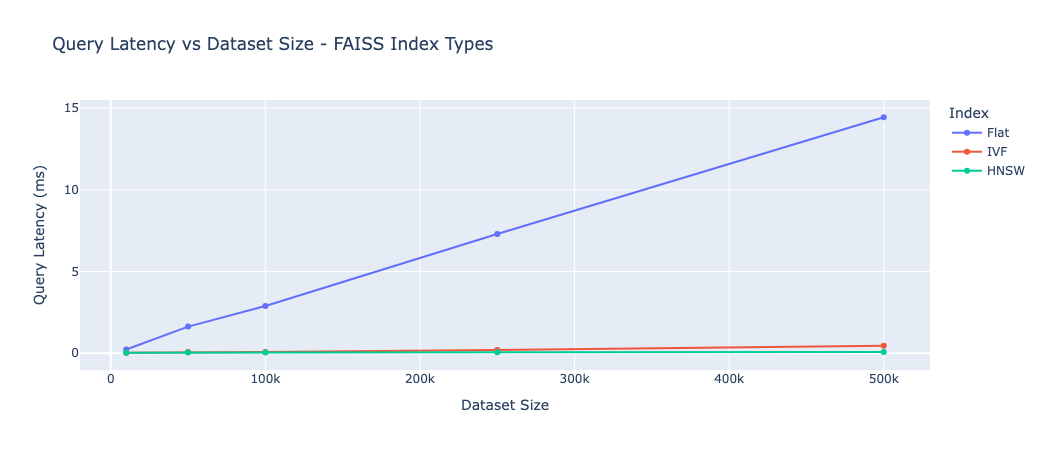

In [16]:
fig = px.line(
    df_scale.melt(id_vars = "size", var_name = "Index", value_name = "latency_ms"),
    x = "size",
    y = "latency_ms",
    color = "Index",
    markers = True,
    title = "Query Latency vs Dataset Size - FAISS Index Types",
    labels = {"size": "Dataset Size", "latency_ms": "Query Latency (ms)"},
)
fig.update_layout(width = 850, height = 450)
fig.show()

## 10. Save the Flat Index as Ground Truth

Every subsequent chapter measures recall against the exact results from this flat index. We save the top-10 results for every record in the dataset so later notebooks can load them without rebuilding the index.

In [17]:
# Compute ground truth on a sample of 1,000 queries
N_QUERY_SAMPLE = 1_000
np.random.seed(42)
sample_indices  = np.random.choice(len(embeddings), N_QUERY_SAMPLE, replace = False)
query_sample    = embeddings[sample_indices]

print(f"Computing ground truth for {N_QUERY_SAMPLE:,} sampled queries...")
start = time.perf_counter()
_, ground_truth = index_flat.search(query_sample, K + 1)
elapsed = time.perf_counter() - start

ground_truth = ground_truth[:, 1:]

np.save("data/nordvik_ground_truth.npy", ground_truth)
np.save("data/nordvik_ground_truth_indices.npy", sample_indices)

print(f"OK  Ground truth computed ({elapsed:.1f}s)")
print(f"    Shape: {ground_truth.shape}")
print(f"    Saved: data/nordvik_ground_truth.npy")
print(f"    Saved: data/nordvik_ground_truth_indices.npy")

Computing ground truth for 1,000 sampled queries...
OK  Ground truth computed (0.5s)
    Shape: (1000, 10)
    Saved: data/nordvik_ground_truth.npy
    Saved: data/nordvik_ground_truth_indices.npy


## 11. What You Would Hit in Production

FAISS is a library, not a service. It has no built-in persistence - you must serialize indexes yourself using `faiss.write_index` and `faiss.read_index`. There is no server, no authentication and no replication. For a production deployment you would wrap FAISS in a service layer or move to a managed vector database.

The IVF index requires training data that is representative of your full dataset. If your data distribution shifts over time the index will degrade and need retraining. HNSW does not require training but consumes significantly more memory than IVF at the same dataset size.

## 12. When to Look Elsewhere

FAISS is the wrong choice if:

- You need metadata filtering alongside vector search - FAISS has no awareness of structured fields
- Your dataset does not fit in RAM - FAISS is an in-memory library; look at LanceDB (Day 7) for disk-based alternatives
- You need a persistent, queryable store rather than a search index - look at Chroma (Day 6)
- You want automatic parameter tuning - the `faiss.AutoTune` API exists but is rarely used in practice; other libraries handle this more gracefully